# Genesys Transcription Latency Analysis

Analyzes production transcript data from `calls/` directory to calculate latency metrics from **audio spoken to transcription received**.

**Data**: 149 conversations captured via Genesys Cloud WebSocket notifications.

**Latency formula**:
```
conversation_start_time = min(receivedAt - (offsetMs + durationMs) / 1000)  -- across all events
audio_finish_time = conversation_start_time + (offsetMs + durationMs) / 1000
latency = receivedAt - audio_finish_time
```

**How `conversation_start_time` is estimated**: For each event, `receivedAt - (offsetMs + durationMs) / 1000` is an upper bound on when the conversation started (assuming latency >= 0). The minimum across all events gives the tightest bound — the anchor event gets latency = 0, and all others are positive. This slightly underestimates true latencies since the anchor event's real latency is > 0, but it avoids negative values and produces the least biased estimate possible without an external clock reference.

See `docs/genesys_transcript_field_analysis.md` for field definitions.

---
## Module 1: Environment Setup & Configuration

In [21]:
import json
import warnings
from datetime import datetime, timezone
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_style("whitegrid")
warnings.filterwarnings("ignore", category=FutureWarning)

# Configuration - adjust these as needed
CALLS_DIR = Path("..") / "calls"
OUTPUT_DIR = Path("..") / "analysis_results"
SAMPLE_SIZE: Optional[int] = None  # None = all files, or integer for testing
SAVE_DPI = 300

# Validate directories
assert CALLS_DIR.exists(), f"Data directory not found: {CALLS_DIR.resolve()}"

jsonl_files = sorted(CALLS_DIR.glob("*.jsonl"))
print(f"Data directory: {CALLS_DIR.resolve()}")
print(f"JSONL files found: {len(jsonl_files)}")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Output directory: {OUTPUT_DIR.resolve()}")

Data directory: /Users/xnxn040/PycharmProjects/notifications-spike/calls
JSONL files found: 149
Output directory: /Users/xnxn040/PycharmProjects/notifications-spike/analysis_results


---
## Module 2: Data Loading

In [22]:
def load_conversation_file(file_path: Path) -> List[Dict[str, Any]]:
    """Load a single JSONL conversation file, skipping malformed lines."""
    events: List[Dict[str, Any]] = []
    with file_path.open("r", encoding="utf-8") as f:
        for line_num, line in enumerate(f, start=1):
            line = line.strip()
            if not line:
                continue
            try:
                event = json.loads(line)
            except json.JSONDecodeError:
                print(f"  WARNING: Malformed JSON at {file_path.name}:{line_num}, skipping")
                continue
            # Validate required fields
            if not all(k in event for k in ("conversationId", "receivedAt", "transcript")):
                print(f"  WARNING: Missing required fields at {file_path.name}:{line_num}, skipping")
                continue
            transcript = event["transcript"]
            alternatives = transcript.get("alternatives", [])
            if not alternatives:
                print(f"  WARNING: No alternatives at {file_path.name}:{line_num}, skipping")
                continue
            events.append(event)
    return events


def load_all_conversations(
    calls_dir: Path,
    sample_size: Optional[int] = None,
) -> Dict[str, List[Dict[str, Any]]]:
    """Load all JSONL files into a dict keyed by conversation ID."""
    files = sorted(calls_dir.glob("*.jsonl"))
    if sample_size is not None:
        files = files[:sample_size]

    conversations: Dict[str, List[Dict[str, Any]]] = {}
    total_events = 0
    errors = 0

    for i, file_path in enumerate(files):
        if (i + 1) % 50 == 0:
            print(f"  Loading file {i + 1}/{len(files)}...")
        try:
            events = load_conversation_file(file_path)
            if events:
                conv_id = events[0]["conversationId"]
                conversations[conv_id] = events
                total_events += len(events)
        except Exception as e:
            print(f"  ERROR loading {file_path.name}: {e}")
            errors += 1

    print(f"\nData Loading Summary:")
    print(f"  Files processed: {len(files)}")
    print(f"  Conversations loaded: {len(conversations)}")
    print(f"  Total events: {total_events}")
    print(f"  Files with errors: {errors}")

    # Date range
    all_timestamps = [
        e["receivedAt"]
        for evts in conversations.values()
        for e in evts
    ]
    if all_timestamps:
        min_dt = datetime.fromtimestamp(min(all_timestamps), tz=timezone.utc)
        max_dt = datetime.fromtimestamp(max(all_timestamps), tz=timezone.utc)
        print(f"  Date range: {min_dt:%Y-%m-%d %H:%M} to {max_dt:%Y-%m-%d %H:%M} UTC")

    return conversations

In [23]:
conversations = load_all_conversations(CALLS_DIR, sample_size=SAMPLE_SIZE)

  Loading file 50/149...
  Loading file 100/149...

Data Loading Summary:
  Files processed: 149
  Conversations loaded: 149
  Total events: 8737
  Files with errors: 0
  Date range: 2025-10-03 00:51 to 2025-10-15 21:03 UTC


---
## Module 3: Latency Calculation

In [24]:
def calculate_conversation_latency(
    events: List[Dict[str, Any]],
    conversation_id: str,
) -> Optional[pd.DataFrame]:
    """Calculate latency for each event in a conversation.

    Estimates conversation_start_time as the minimum of
    (receivedAt - (offsetMs + durationMs) / 1000) across all events.
    This is the tightest upper bound that keeps all latencies >= 0.

    Single-event conversations are skipped because the sole event
    always produces latency = 0 by construction (it is its own anchor).
    """
    if len(events) < 2:
        return None

    # Estimate conversation start: min upper-bound across all events
    # Each event's upper bound = receivedAt - (audio_end_offset / 1000)
    conversation_start_time = min(
        e["receivedAt"] - (e["transcript"]["alternatives"][0]["offsetMs"]
                           + e["transcript"]["alternatives"][0]["durationMs"]) / 1000.0
        for e in events
    )

    rows: List[Dict[str, Any]] = []
    for event in events:
        transcript = event["transcript"]
        alt = transcript["alternatives"][0]

        offset_ms = alt["offsetMs"]
        duration_ms = alt["durationMs"]
        received_at = event["receivedAt"]

        audio_end_ms = offset_ms + duration_ms
        audio_finish_time = conversation_start_time + (audio_end_ms / 1000.0)
        latency_seconds = received_at - audio_finish_time

        transcript_text = alt.get("transcript", "")
        decorated_text = alt.get("decoratedTranscript", transcript_text)

        rows.append({
            "conversation_id": conversation_id,
            "utterance_id": transcript.get("utteranceId", ""),
            "channel": transcript.get("channel", "UNKNOWN"),
            "is_final": transcript.get("isFinal", False),
            "offset_ms": offset_ms,
            "duration_ms": duration_ms,
            "audio_finish_time": audio_finish_time,
            "received_at": received_at,
            "latency_seconds": latency_seconds,
            "confidence": alt.get("confidence", np.nan),
            "transcript_text": transcript_text,
            "decorated_text": decorated_text,
            "word_count": len(transcript_text.split()) if transcript_text else 0,
        })

    df = pd.DataFrame(rows)

    # Flag anomalies
    df["anomaly"] = "normal"
    df.loc[df["latency_seconds"] > 60, "anomaly"] = "extreme_high"
    df.loc[
        (df["latency_seconds"] > 5) & (df["latency_seconds"] <= 60),
        "anomaly",
    ] = "high"

    return df


def calculate_all_latencies(
    conversations: Dict[str, List[Dict[str, Any]]],
) -> pd.DataFrame:
    """Calculate latencies for all conversations, adding time-of-day metadata."""
    frames: List[pd.DataFrame] = []
    skipped = 0

    for conv_id, events in conversations.items():
        df = calculate_conversation_latency(events, conv_id)
        if df is None:
            skipped += 1
            continue
        frames.append(df)

    if not frames:
        raise ValueError("No conversations produced latency data")

    result = pd.concat(frames, ignore_index=True)

    # Add time metadata
    result["received_dt"] = pd.to_datetime(result["received_at"], unit="s", utc=True)
    result["conversation_date"] = result["received_dt"].dt.date
    result["hour_of_day"] = result["received_dt"].dt.hour
    result["day_of_week"] = result["received_dt"].dt.day_name()

    print(f"Latency Calculation Summary:")
    print(f"  Conversations processed: {len(frames)}")
    print(f"  Conversations skipped (<2 events): {skipped}")
    print(f"  Total utterances: {len(result)}")
    print(f"  Anchor events (latency=0): {(result['latency_seconds'] == 0).sum()}")
    print(f"  Latency > 5s: {(result['latency_seconds'] > 5).sum()}")

    return result

In [25]:
df_latency = calculate_all_latencies(conversations)
df_latency.head()

Latency Calculation Summary:
  Conversations processed: 147
  Conversations skipped (<2 events): 2
  Total utterances: 8735
  Anchor events (latency=0): 147
  Latency > 5s: 30


,conversation_id,utterance_id,channel,is_final,offset_ms,duration_ms,audio_finish_time,received_at,latency_seconds,confidence,transcript_text,decorated_text,word_count,anomaly,received_dt,conversation_date,hour_of_day,day_of_week
0,02ecc434-d65b-491e-9555-59aa3949d046,469770cb-290b-49fb-9525-d682241c3c01,INTERNAL,True,43659,3883,1.759456e+09,1.759456e+09,1.419030,0.990000,thank you for calling grainger my name is anne...,thank you for calling grainger my name is anne...,14,normal,2025-10-03 01:54:57.216861010+00:00,2025-10-03,1,Friday
1,02ecc434-d65b-491e-9555-59aa3949d046,ee9a71b2-c23f-4e51-877a-4d1d1050aed1,EXTERNAL,True,49699,10521,1.759457e+09,1.759457e+09,2.046669,0.984190,hi i'm calling because i'm trying to access my...,hi i'm calling because i'm trying to access my...,21,normal,2025-10-03 01:55:10.522500038+00:00,2025-10-03,1,Friday
2,02ecc434-d65b-491e-9555-59aa3949d046,b43739f5-bf9a-4942-a482-4b3ef6f8df30,INTERNAL,True,62577,4564,1.759457e+09,1.759457e+09,2.104180,0.990944,i'm sorry to hear that i'd be happy to assist ...,i'm sorry to hear that i'd be happy to assist ...,18,normal,2025-10-03 01:55:17.501010894+00:00,2025-10-03,1,Friday
3,02ecc434-d65b-491e-9555-59aa3949d046,29ea31fe-44f3-4d70-9d32-56a9b91bf6ed,EXTERNAL,True,72547,36,1.759457e+09,1.759457e+09,1.563717,0.823000,like,like,1,normal,2025-10-03 01:55:22.402548075+00:00,2025-10-03,1,Friday
4,02ecc434-d65b-491e-9555-59aa3949d046,2b6345a4-a68c-4a97-a8e6-c7a0355ab980,EXTERNAL,True,74995,2787,1.759457e+09,1.759457e+09,1.256526,0.969615,like like i'm trying to like i have an account...,like like i'm trying to like i have an account...,13,normal,2025-10-03 01:55:27.294357061+00:00,2025-10-03,1,Friday


---
## Module 4: Aggregation & Summary Statistics

In [26]:
def compute_latency_stats(series: pd.Series, label: str = "Overall") -> Dict[str, Any]:
    """Compute percentile and summary stats for a latency series."""
    clean = series.dropna()
    return {
        "label": label,
        "count": len(clean),
        "mean": clean.mean(),
        "std": clean.std(),
        "min": clean.min(),
        "p25": clean.quantile(0.25),
        "p50": clean.quantile(0.50),
        "p75": clean.quantile(0.75),
        "p90": clean.quantile(0.90),
        "p95": clean.quantile(0.95),
        "p99": clean.quantile(0.99),
        "max": clean.max(),
    }


def build_summary(
    df: pd.DataFrame,
) -> Tuple[Dict[str, Any], pd.DataFrame]:
    """Build full summary statistics dict and channel comparison DataFrame."""
    overall = compute_latency_stats(df["latency_seconds"], "Overall")

    # Channel breakdown
    channel_stats = []
    for channel in sorted(df["channel"].unique()):
        mask = df["channel"] == channel
        channel_stats.append(
            compute_latency_stats(df.loc[mask, "latency_seconds"], channel)
        )

    # Confidence quartile breakdown (all events are isFinal=True, so finality breakdown is useless)
    df = df.copy()
    df["confidence_quartile"] = pd.qcut(
        df["confidence"], q=4, labels=["Q1 (low)", "Q2", "Q3", "Q4 (high)"]
    )
    confidence_stats = []
    for q in ["Q1 (low)", "Q2", "Q3", "Q4 (high)"]:
        mask = df["confidence_quartile"] == q
        confidence_stats.append(
            compute_latency_stats(df.loc[mask, "latency_seconds"], f"Confidence {q}")
        )

    # Correlations
    correlations = {
        "latency_vs_duration": df["latency_seconds"].corr(df["duration_ms"]),
        "latency_vs_confidence": df["latency_seconds"].corr(df["confidence"]),
        "latency_vs_word_count": df["latency_seconds"].corr(df["word_count"]),
    }

    # Anomaly counts
    anomalies = {
        "anchor_events_zero": int((df["latency_seconds"] == 0).sum()),
        "above_5s": int((df["latency_seconds"] > 5).sum()),
        "above_10s": int((df["latency_seconds"] > 10).sum()),
    }

    # Top 10 worst conversations
    top10 = (
        df.groupby("conversation_id")["latency_seconds"]
        .max()
        .nlargest(10)
        .to_dict()
    )

    summary = {
        "overall": overall,
        "by_channel": channel_stats,
        "by_confidence_quartile": confidence_stats,
        "correlations": correlations,
        "anomalies": anomalies,
        "top10_worst_conversations": top10,
        "metadata": {
            "total_conversations": df["conversation_id"].nunique(),
            "total_utterances": len(df),
            "date_range_start": str(df["received_dt"].min()),
            "date_range_end": str(df["received_dt"].max()),
            "all_events_are_final": bool(df["is_final"].all()),
            "estimation_note": (
                "conversation_start_time is estimated as the min upper-bound across all events. "
                "The anchor event has latency=0; all others are relative to it. True latencies "
                "are slightly higher since the anchor event's real latency is > 0."
            ),
        },
    }

    # Build comparison DataFrame for display
    stats_rows = [overall] + channel_stats
    df_stats = pd.DataFrame(stats_rows).set_index("label")

    return summary, df_stats

In [27]:
summary, df_stats = build_summary(df_latency)

print("=" * 70)
print("LATENCY SUMMARY (seconds)")
print("=" * 70)
display(df_stats.round(3))

print("\nCorrelations:")
for k, v in summary["correlations"].items():
    print(f"  {k}: {v:.4f}")

print("\nAnomaly Counts:")
for k, v in summary["anomalies"].items():
    print(f"  {k}: {v}")

print("\nConfidence Quartile Breakdown:")
df_conf = pd.DataFrame(summary["by_confidence_quartile"]).set_index("label")
display(df_conf[["count", "mean", "p50", "p95", "p99"]].round(3))

LATENCY SUMMARY (seconds)


,count,mean,std,min,p25,p50,p75,p90,p95,p99,max
label,,,,,,,,,,,
Overall,8735,0.938,0.772,0.0,0.509,0.837,1.179,1.626,2.003,3.304,18.636
EXTERNAL,4401,0.880,0.731,0.0,0.466,0.790,1.112,1.526,1.890,3.215,14.015
INTERNAL,4334,0.998,0.808,0.0,0.559,0.887,1.258,1.712,2.090,3.433,18.636



Correlations:
  latency_vs_duration: 0.2291
  latency_vs_confidence: 0.0124
  latency_vs_word_count: 0.1968

Anomaly Counts:
  anchor_events_zero: 147
  above_5s: 30
  above_10s: 9

Confidence Quartile Breakdown:


,count,mean,p50,p95,p99
label,,,,,
Confidence Q1 (low),2184,0.898,0.777,2.006,3.340
Confidence Q2,2184,0.970,0.880,2.101,3.315
Confidence Q3,2183,0.987,0.881,2.023,3.253
Confidence Q4 (high),2184,0.899,0.807,1.888,3.208


---
## Module 5: Visualizations

In [28]:
# All latencies are >= 0 with the corrected formula; exclude anchor events (latency=0) from viz
df_viz = df_latency[df_latency["latency_seconds"] > 0].copy()

### Chart 1: Latency Distribution Histogram

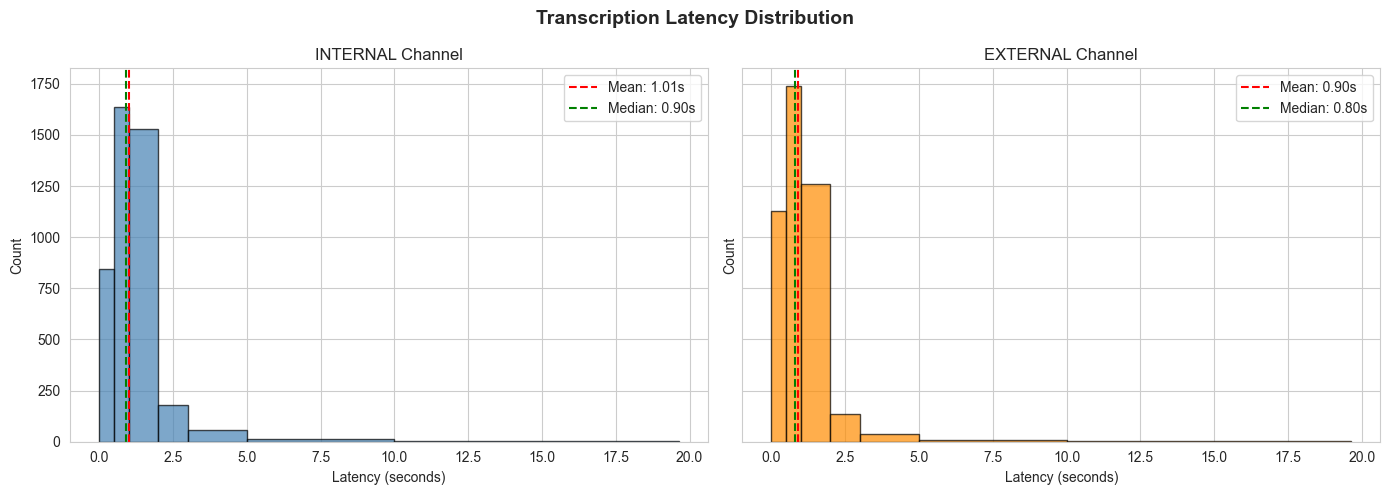

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

bins = [0, 0.5, 1, 2, 3, 5, 10, df_viz["latency_seconds"].max() + 1]

for ax, channel in zip(axes, ["INTERNAL", "EXTERNAL"]):
    data = df_viz.loc[df_viz["channel"] == channel, "latency_seconds"]
    ax.hist(data, bins=bins, edgecolor="black", alpha=0.7, color="steelblue" if channel == "INTERNAL" else "darkorange")
    ax.axvline(data.mean(), color="red", linestyle="--", label=f"Mean: {data.mean():.2f}s")
    ax.axvline(data.median(), color="green", linestyle="--", label=f"Median: {data.median():.2f}s")
    ax.set_title(f"{channel} Channel")
    ax.set_xlabel("Latency (seconds)")
    ax.set_ylabel("Count")
    ax.legend()

fig.suptitle("Transcription Latency Distribution", fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "latency_distribution.png", dpi=SAVE_DPI, bbox_inches="tight")
plt.show()

### Chart 2: Latency Over Time

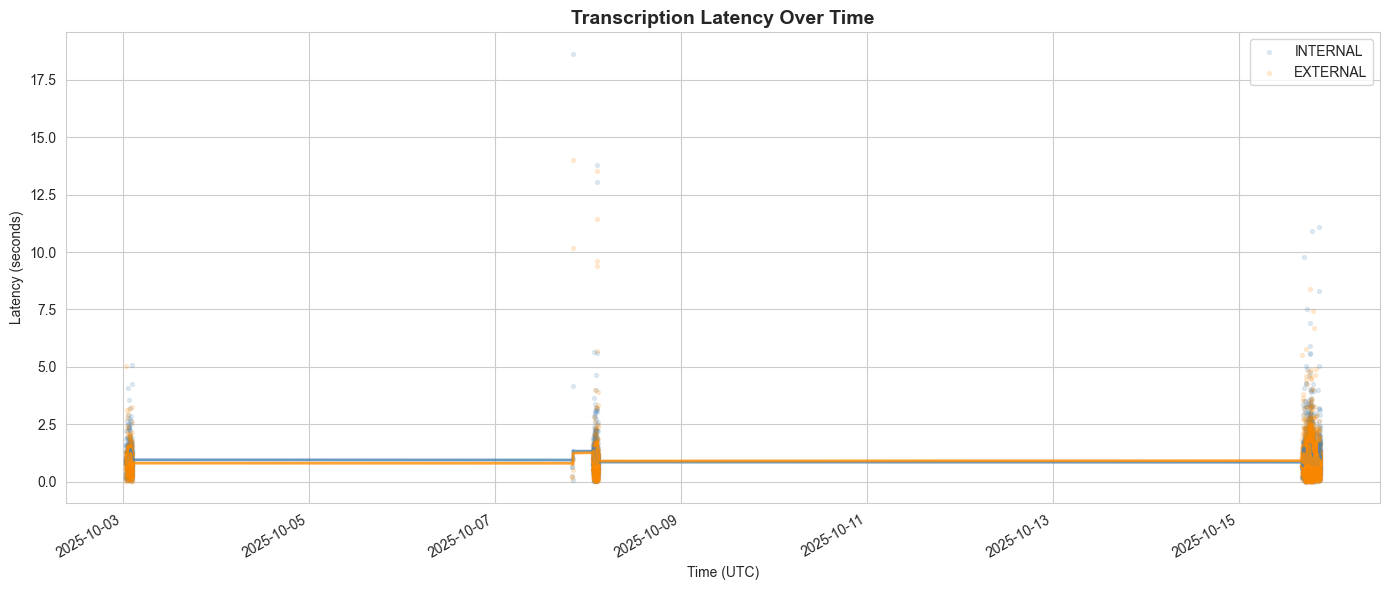

In [10]:
fig, ax = plt.subplots(figsize=(14, 6))

for channel, color in [("INTERNAL", "steelblue"), ("EXTERNAL", "darkorange")]:
    mask = df_viz["channel"] == channel
    subset = df_viz[mask].sort_values("received_dt")
    ax.scatter(
        subset["received_dt"], subset["latency_seconds"],
        alpha=0.15, s=8, color=color, label=channel,
    )
    # Rolling average
    if len(subset) >= 50:
        rolling = subset["latency_seconds"].rolling(window=50, min_periods=10).mean()
        ax.plot(subset["received_dt"].values, rolling.values, color=color, linewidth=2, alpha=0.8)

ax.set_xlabel("Time (UTC)")
ax.set_ylabel("Latency (seconds)")
ax.set_title("Transcription Latency Over Time", fontsize=14, fontweight="bold")
ax.legend()
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "latency_over_time.png", dpi=SAVE_DPI, bbox_inches="tight")
plt.show()

### Chart 3: Percentile Comparison by Channel

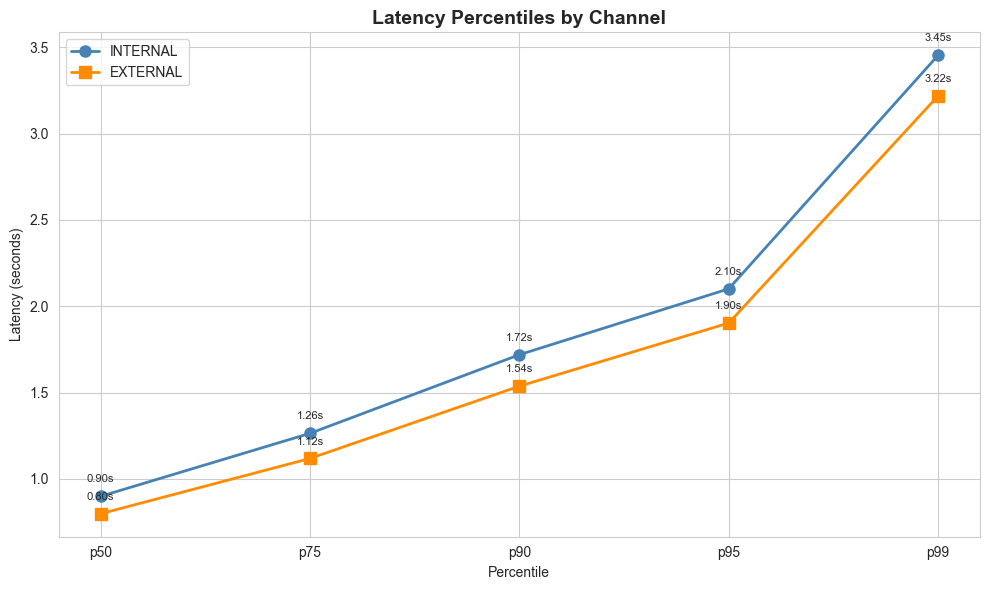

In [11]:
percentiles = [0.50, 0.75, 0.90, 0.95, 0.99]
pct_labels = ["p50", "p75", "p90", "p95", "p99"]

fig, ax = plt.subplots(figsize=(10, 6))

for channel, color, marker in [("INTERNAL", "steelblue", "o"), ("EXTERNAL", "darkorange", "s")]:
    data = df_viz.loc[df_viz["channel"] == channel, "latency_seconds"]
    values = [data.quantile(p) for p in percentiles]
    ax.plot(pct_labels, values, marker=marker, color=color, linewidth=2, markersize=8, label=channel)
    for label, val in zip(pct_labels, values):
        ax.annotate(f"{val:.2f}s", (label, val), textcoords="offset points", xytext=(0, 10), ha="center", fontsize=8)

ax.set_xlabel("Percentile")
ax.set_ylabel("Latency (seconds)")
ax.set_title("Latency Percentiles by Channel", fontsize=14, fontweight="bold")
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "latency_percentiles.png", dpi=SAVE_DPI, bbox_inches="tight")
plt.show()

### Chart 4: Box Plot by Channel

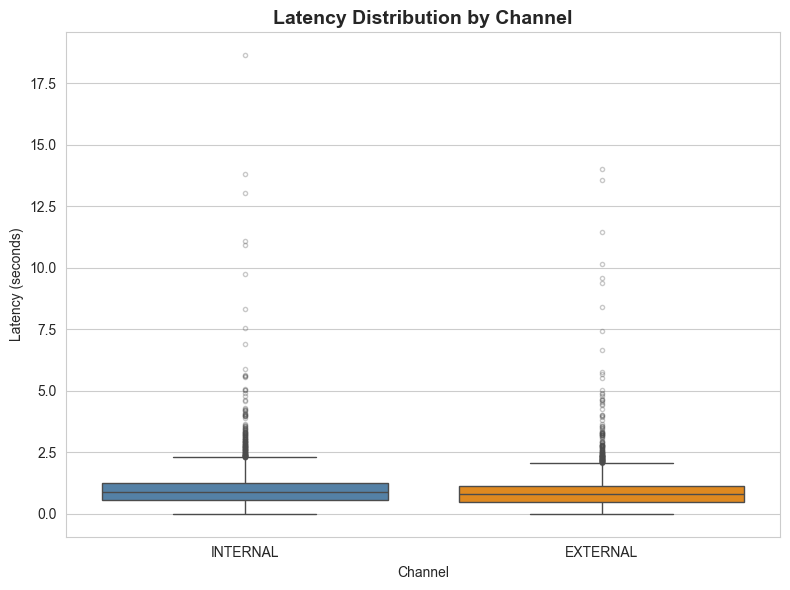

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.boxplot(
    data=df_viz, x="channel", y="latency_seconds",
    palette={"INTERNAL": "steelblue", "EXTERNAL": "darkorange"},
    ax=ax, showfliers=True, flierprops={"marker": ".", "alpha": 0.3},
)
ax.set_xlabel("Channel")
ax.set_ylabel("Latency (seconds)")
ax.set_title("Latency Distribution by Channel", fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "latency_boxplot.png", dpi=SAVE_DPI, bbox_inches="tight")
plt.show()

### Chart 5: Latency vs Audio Duration

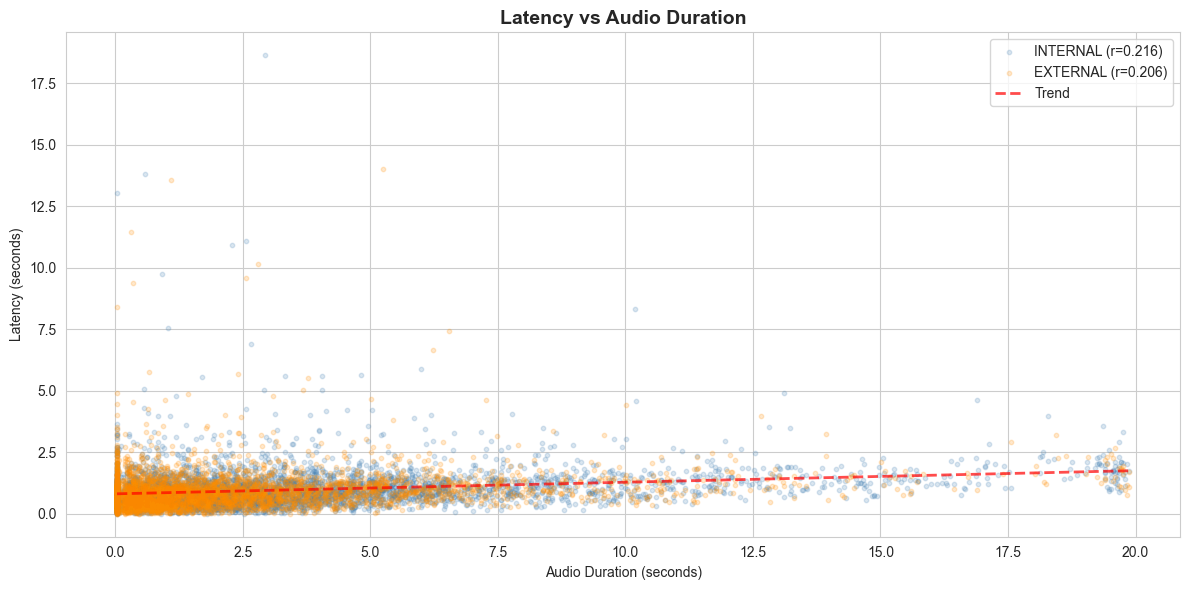

In [13]:
fig, ax = plt.subplots(figsize=(12, 6))

df_viz["duration_s"] = df_viz["duration_ms"] / 1000.0

for channel, color in [("INTERNAL", "steelblue"), ("EXTERNAL", "darkorange")]:
    mask = df_viz["channel"] == channel
    subset = df_viz[mask]
    corr = subset["latency_seconds"].corr(subset["duration_s"])
    ax.scatter(
        subset["duration_s"], subset["latency_seconds"],
        alpha=0.2, s=10, color=color, label=f"{channel} (r={corr:.3f})",
    )

# Overall trend line
mask_valid = df_viz["duration_s"].notna() & df_viz["latency_seconds"].notna()
z = np.polyfit(df_viz.loc[mask_valid, "duration_s"], df_viz.loc[mask_valid, "latency_seconds"], 1)
p = np.poly1d(z)
x_range = np.linspace(df_viz["duration_s"].min(), df_viz["duration_s"].max(), 100)
ax.plot(x_range, p(x_range), "r--", linewidth=2, alpha=0.7, label="Trend")

ax.set_xlabel("Audio Duration (seconds)")
ax.set_ylabel("Latency (seconds)")
ax.set_title("Latency vs Audio Duration", fontsize=14, fontweight="bold")
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "latency_vs_duration.png", dpi=SAVE_DPI, bbox_inches="tight")
plt.show()

### Chart 6: Heatmap — Latency by Date and Hour

Data spans ~13 days across 9 hours (12-17, 20-22 UTC), so the Y-axis uses calendar date rather than day-of-week.

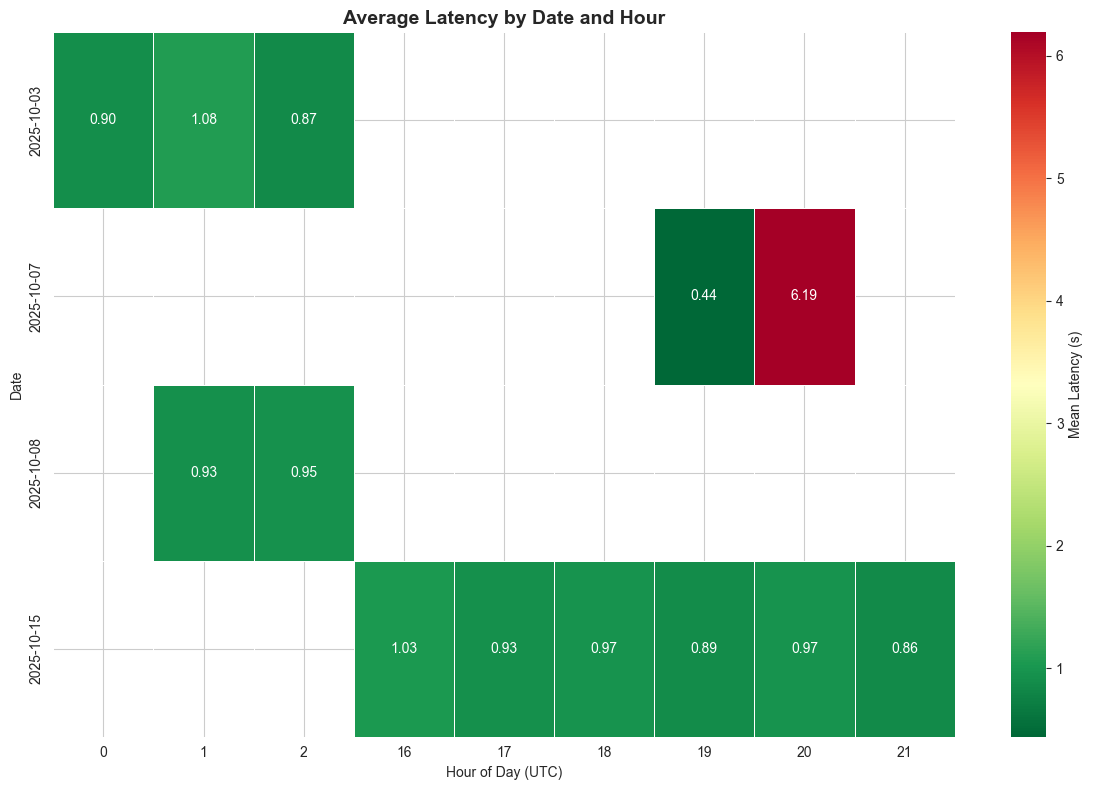

In [14]:
pivot = df_viz.pivot_table(
    values="latency_seconds",
    index="conversation_date",
    columns="hour_of_day",
    aggfunc="mean",
)
# Sort index chronologically
pivot = pivot.sort_index()

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(
    pivot, cmap="RdYlGn_r", annot=True, fmt=".2f",
    linewidths=0.5, ax=ax, cbar_kws={"label": "Mean Latency (s)"},
)
ax.set_xlabel("Hour of Day (UTC)")
ax.set_ylabel("Date")
ax.set_title("Average Latency by Date and Hour", fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "latency_heatmap.png", dpi=SAVE_DPI, bbox_inches="tight")
plt.show()

---
## Module 6: Export Results

In [15]:
def export_results(
    df: pd.DataFrame,
    summary_stats: Dict[str, Any],
    output_dir: Path,
) -> Path:
    """Export all analysis results to a timestamped subdirectory and 'latest' copies."""
    import shutil

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    run_dir = output_dir / f"run_{timestamp}"
    run_dir.mkdir(parents=True, exist_ok=True)

    # -- latency_summary.json --
    def _make_serializable(obj: Any) -> Any:
        if isinstance(obj, (np.integer,)):
            return int(obj)
        if isinstance(obj, (np.floating,)):
            return float(obj)
        if isinstance(obj, (np.bool_,)):
            return bool(obj)
        if isinstance(obj, dict):
            return {k: _make_serializable(v) for k, v in obj.items()}
        if isinstance(obj, (list, tuple)):
            return [_make_serializable(i) for i in obj]
        return obj

    summary_path = run_dir / "latency_summary.json"
    with summary_path.open("w", encoding="utf-8") as f:
        json.dump(_make_serializable(summary_stats), f, indent=2, default=str)

    # -- latency_detailed.csv --
    export_cols = [
        "conversation_id", "utterance_id", "channel", "is_final",
        "offset_ms", "duration_ms", "audio_finish_time", "received_at",
        "latency_seconds", "confidence", "transcript_text", "word_count", "anomaly",
        "received_dt", "conversation_date", "hour_of_day", "day_of_week",
    ]
    cols_present = [c for c in export_cols if c in df.columns]
    df_export = df[cols_present].sort_values("received_at")
    df_export.to_csv(run_dir / "latency_detailed.csv", index=False)

    # -- latency_by_channel.csv --
    channel_rows = []
    for label, subset in [("OVERALL", df)] + [
        (ch, df[df["channel"] == ch]) for ch in sorted(df["channel"].unique())
    ]:
        s = subset["latency_seconds"]
        channel_rows.append({
            "channel": label, "count": len(s),
            "mean": s.mean(), "median": s.median(),
            "p75": s.quantile(0.75), "p95": s.quantile(0.95), "p99": s.quantile(0.99),
            "std": s.std(),
        })
    pd.DataFrame(channel_rows).to_csv(run_dir / "latency_by_channel.csv", index=False)

    # -- latency_by_conversation.csv --
    conv_agg = (
        df.groupby("conversation_id")
        .agg(
            event_count=("latency_seconds", "count"),
            mean_latency=("latency_seconds", "mean"),
            max_latency=("latency_seconds", "max"),
            total_duration_ms=("duration_ms", "sum"),
        )
        .sort_values("mean_latency", ascending=False)
    )
    conv_agg.to_csv(run_dir / "latency_by_conversation.csv")

    # -- anomalies.csv (events with latency > 5s) --
    df_anomalies = df[df["latency_seconds"] > 5].copy()
    df_anomalies = df_anomalies.sort_values("latency_seconds", ascending=False)
    anomaly_cols = [
        "conversation_id", "utterance_id", "channel", "latency_seconds",
        "offset_ms", "duration_ms", "confidence", "transcript_text", "anomaly",
    ]
    df_anomalies[[c for c in anomaly_cols if c in df_anomalies.columns]].to_csv(
        run_dir / "anomalies.csv", index=False
    )

    # -- Copy PNGs into run dir --
    for png in output_dir.glob("*.png"):
        shutil.copy2(png, run_dir / png.name)

    # -- Latest copies at top level --
    for name in ["latency_summary.json", "latency_detailed.csv", "latency_by_channel.csv",
                 "latency_by_conversation.csv", "anomalies.csv"]:
        src = run_dir / name
        if src.exists():
            shutil.copy2(src, output_dir / name)

    print(f"Results exported to: {run_dir.resolve()}")
    print(f"Latest copies at: {output_dir.resolve()}")
    for f in sorted(run_dir.iterdir()):
        print(f"  {f.name} ({f.stat().st_size / 1024:.1f} KB)")

    return run_dir

In [16]:
run_dir = export_results(df_latency, summary, OUTPUT_DIR)

Results exported to: /Users/xnxn040/PycharmProjects/notifications-spike/analysis_results/run_20260318_171748
Latest copies at: /Users/xnxn040/PycharmProjects/notifications-spike/analysis_results
  anomalies.csv (5.3 KB)
  latency_boxplot.png (91.8 KB)
  latency_by_channel.csv (0.4 KB)
  latency_by_conversation.csv (12.1 KB)
  latency_detailed.csv (2478.8 KB)
  latency_distribution.png (132.9 KB)
  latency_heatmap.png (146.2 KB)
  latency_over_time.png (201.5 KB)
  latency_percentiles.png (178.8 KB)
  latency_summary.json (4.0 KB)
  latency_vs_duration.png (705.1 KB)


---
## Module 7: Conversation Deep-Dive Analysis

In [17]:
def analyze_conversation(
    conversation_id: str,
    df: pd.DataFrame,
) -> None:
    """Print detailed analysis and timeline visualization for one conversation."""
    conv = df[df["conversation_id"] == conversation_id].sort_values("offset_ms").copy()
    if conv.empty:
        print(f"No data for conversation {conversation_id}")
        return

    # -- Metadata --
    duration_s = (conv["offset_ms"].max() + conv["duration_ms"].iloc[-1] - conv["offset_ms"].min()) / 1000.0

    print("=" * 70)
    print(f"CONVERSATION: {conversation_id}")
    print("=" * 70)
    print(f"  Utterances:    {len(conv)}")
    print(f"  Duration:      {duration_s:.1f}s")
    print(f"  Channels:      {', '.join(sorted(conv['channel'].unique()))}")
    print(f"  Mean latency:  {conv['latency_seconds'].mean():.3f}s")
    print(f"  Max latency:   {conv['latency_seconds'].max():.3f}s")
    print(f"  Min latency:   {conv['latency_seconds'].min():.3f}s")

    # -- Timeline chart --
    fig, ax = plt.subplots(figsize=(14, 4))
    channel_y = {"INTERNAL": 1, "EXTERNAL": 0}

    for _, row in conv.iterrows():
        y = channel_y.get(row["channel"], 0.5)
        start_s = row["offset_ms"] / 1000.0
        dur_s = row["duration_ms"] / 1000.0
        latency = row["latency_seconds"]

        # Color by latency
        if latency == 0:
            color = "lightblue"  # anchor event
        elif latency < 1:
            color = "green"
        elif latency < 3:
            color = "orange"
        else:
            color = "red"

        ax.barh(y, dur_s, left=start_s, height=0.3, color=color, alpha=0.7, edgecolor="black", linewidth=0.5)

    ax.set_yticks([0, 1])
    ax.set_yticklabels(["EXTERNAL", "INTERNAL"])
    ax.set_xlabel("Time from conversation start (seconds)")
    ax.set_title(f"Conversation Timeline — {conversation_id[:12]}...", fontweight="bold")

    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor="lightblue", alpha=0.7, label="anchor (0s)"),
        Patch(facecolor="green", alpha=0.7, label="< 1s"),
        Patch(facecolor="orange", alpha=0.7, label="1-3s"),
        Patch(facecolor="red", alpha=0.7, label="> 3s"),
    ]
    ax.legend(handles=legend_elements, loc="upper right", title="Latency")
    fig.tight_layout()
    plt.show()

    # -- Annotated transcript --
    print("\nAnnotated Transcript:")
    print("-" * 70)
    for _, row in conv.iterrows():
        offset_s = row["offset_ms"] / 1000.0
        mins, secs = divmod(offset_s, 60)
        timestamp = f"{int(mins):02d}:{secs:05.2f}"
        lat = row["latency_seconds"]
        marker = "!!" if lat > 3 else "  "
        text = row.get("decorated_text", row["transcript_text"])
        conf = row["confidence"]
        print(f"{marker} [{timestamp}] [{row['channel']:<8}] [Lat: {lat:.2f}s] [Conf: {conf:.2f}] {text}")
    print()

Top 5 conversations by max latency:

CONVERSATION: 358b269d-0af6-4649-b974-b14c8e84ed63
  Utterances:    9
  Duration:      34.1s
  Channels:      EXTERNAL, INTERNAL
  Mean latency:  5.504s
  Max latency:   18.636s
  Min latency:   0.000s


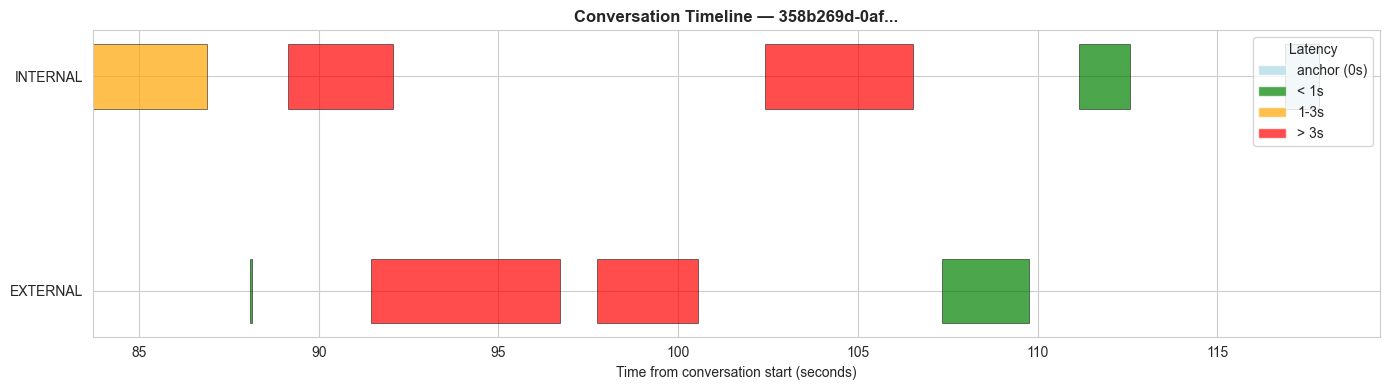


Annotated Transcript:
----------------------------------------------------------------------
   [01:23.72] [INTERNAL] [Lat: 1.01s] [Conf: 0.94] thank you for calling grainger my name is amber he got questions in regards to her return
   [01:28.09] [EXTERNAL] [Lat: 0.52s] [Conf: 1.00] yes
!! [01:29.14] [INTERNAL] [Lat: 18.64s] [Conf: 0.96] can i get that item number i'm sorry the order number whenever you're ready
!! [01:31.46] [EXTERNAL] [Lat: 14.01s] [Conf: 0.95] sure yeah it was a yeah it was a replacement order in that number is 156
!! [01:37.74] [EXTERNAL] [Lat: 10.17s] [Conf: 0.98] 3028-838
!! [01:42.42] [INTERNAL] [Lat: 4.17s] [Conf: 0.99] thank you and can i get your 1st and last name and the company that you are calling with today please
   [01:47.34] [EXTERNAL] [Lat: 0.96s] [Conf: 0.89] my name's rebecca long and i'm calling with cal state supply
   [01:51.15] [INTERNAL] [Lat: 0.05s] [Conf: 0.97] let me pull up your information
   [01:56.88] [INTERNAL] [Lat: 0.00s] [Conf: 0.9

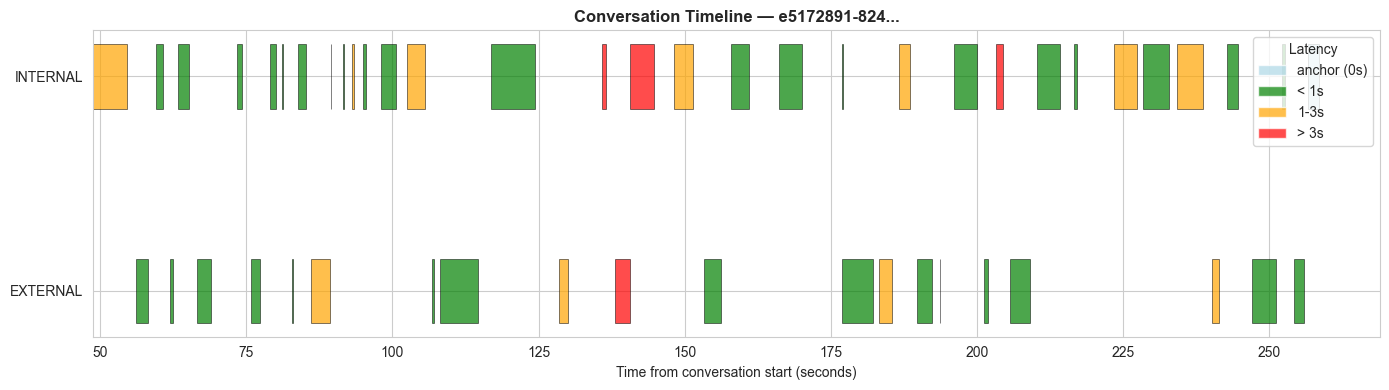


Annotated Transcript:
----------------------------------------------------------------------
   [00:48.78] [INTERNAL] [Lat: 1.01s] [Conf: 1.00] thank you for calling grainger my name is beth May i have your 1st and last name please
   [00:56.14] [EXTERNAL] [Lat: 0.21s] [Conf: 0.62] mr kumar whole day long
   [00:59.62] [INTERNAL] [Lat: 0.67s] [Conf: 0.99] hello how are you doing today
   [01:01.96] [EXTERNAL] [Lat: 0.02s] [Conf: 0.80] i'm doing good
   [01:03.30] [INTERNAL] [Lat: 0.33s] [Conf: 1.00] that's good how May i help you
   [01:06.56] [EXTERNAL] [Lat: 0.57s] [Conf: 0.86] okay grainger part number 29 apples
   [01:13.44] [INTERNAL] [Lat: 0.23s] [Conf: 1.00] 29 apple
   [01:15.89] [EXTERNAL] [Lat: 0.10s] [Conf: 0.67] g as the god want to
   [01:19.06] [INTERNAL] [Lat: 0.48s] [Conf: 0.97] 29 apple guard
   [01:21.14] [INTERNAL] [Lat: 0.12s] [Conf: 1.00] 12
   [01:22.75] [EXTERNAL] [Lat: 0.40s] [Conf: 0.95] that's correct
   [01:23.82] [INTERNAL] [Lat: 0.36s] [Conf: 1.00] and wha

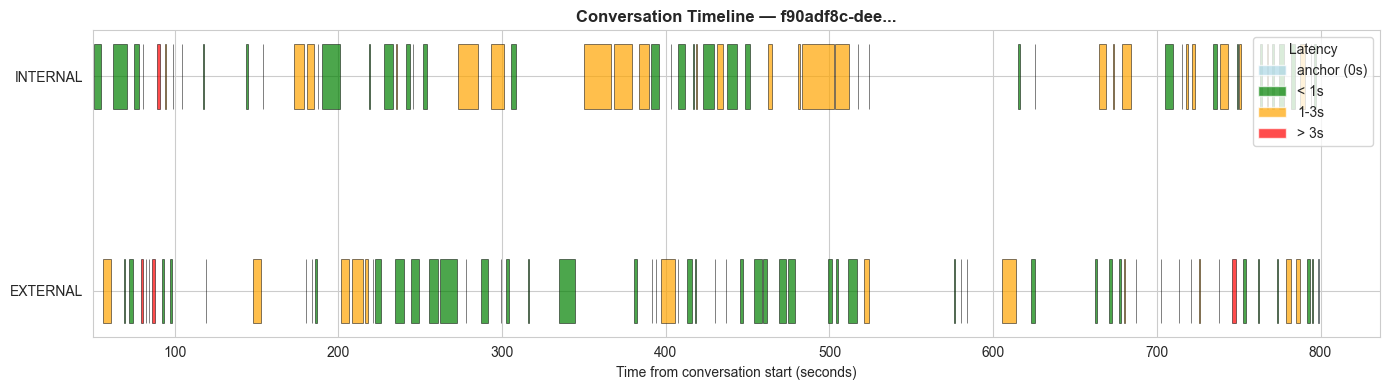


Annotated Transcript:
----------------------------------------------------------------------
   [00:50.04] [EXTERNAL] [Lat: 1.91s] [Conf: 0.25] okay
   [00:50.82] [INTERNAL] [Lat: 0.98s] [Conf: 0.96] thank you for calling grainger my name's steve can i just see that you're looking to place an order
   [00:56.42] [EXTERNAL] [Lat: 1.13s] [Conf: 0.98] yeah actually i just placed an order i just need to add something to it
   [01:02.48] [INTERNAL] [Lat: 0.49s] [Conf: 0.97] alright so the the really the only 2 options we have is to cancel the original order and place a new order or just place a new order for the new item
   [01:09.16] [EXTERNAL] [Lat: 0.41s] [Conf: 0.50] that's fine
   [01:11.98] [EXTERNAL] [Lat: 0.39s] [Conf: 0.92] let's just cancel it because i don't want to pay shipping twice
   [01:15.34] [INTERNAL] [Lat: 0.60s] [Conf: 0.99] okay that makes sense what what information do you have about that order
!! [01:19.26] [EXTERNAL] [Lat: 13.55s] [Conf: 0.78] for the number do you

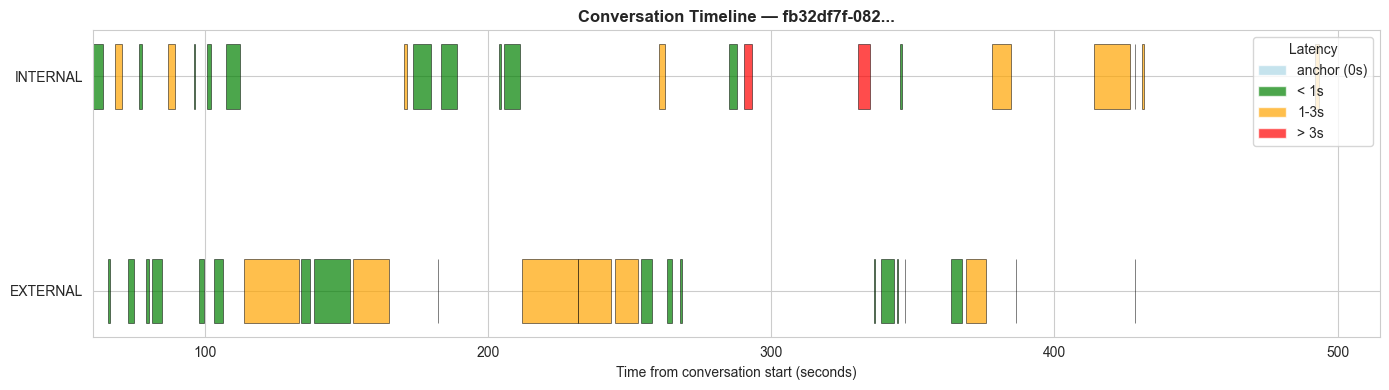


Annotated Transcript:
----------------------------------------------------------------------
   [01:00.54] [INTERNAL] [Lat: 0.66s] [Conf: 0.97] thank you for calling grainger my name is aubrey can we start with your 1st and last name please
   [01:05.70] [EXTERNAL] [Lat: 0.79s] [Conf: 0.90] victor rivera vegas
   [01:08.36] [INTERNAL] [Lat: 1.03s] [Conf: 0.96] thank you and are we calling with the company today victor
   [01:12.90] [EXTERNAL] [Lat: 0.83s] [Conf: 0.84] and you want gonna give you the account number
   [01:16.65] [INTERNAL] [Lat: 0.77s] [Conf: 0.99] yeah what is the account number
   [01:19.20] [EXTERNAL] [Lat: 0.07s] [Conf: 0.99] it is 088
   [01:21.54] [EXTERNAL] [Lat: 0.84s] [Conf: 0.98] 71 47-963
   [01:27.00] [INTERNAL] [Lat: 1.09s] [Conf: 0.94] thank you while i'm getting that loaded here how's your wednesday going
   [01:36.04] [INTERNAL] [Lat: 0.99s] [Conf: 0.98] i'm sorry what was that
   [01:37.86] [EXTERNAL] [Lat: 0.78s] [Conf: 0.81] i'm sorry what was did yo

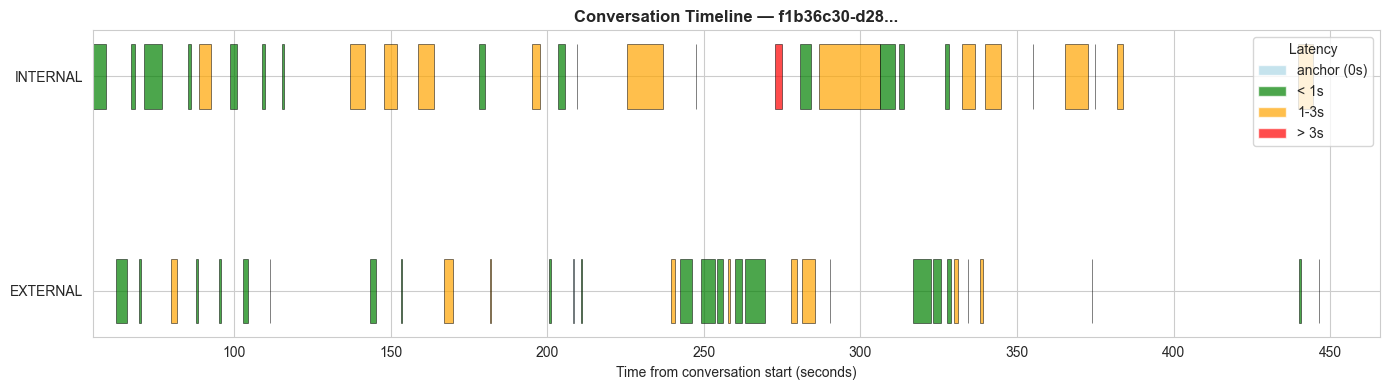


Annotated Transcript:
----------------------------------------------------------------------
   [00:54.92] [INTERNAL] [Lat: 0.88s] [Conf: 0.99] thank you for calling grainger my name is ashley May i have your 1st and last name please
   [01:02.42] [EXTERNAL] [Lat: 0.95s] [Conf: 0.76] okay i see do ya have a part 1st name daniel last name 40
   [01:07.06] [INTERNAL] [Lat: 0.61s] [Conf: 0.89] hi danielle how is it going today
   [01:09.62] [EXTERNAL] [Lat: 0.68s] [Conf: 0.85] alright how are you doing
   [01:11.16] [INTERNAL] [Lat: 0.73s] [Conf: 0.99] i'm doing well thank you so much for asking and are you calling with the company as well
   [01:19.72] [EXTERNAL] [Lat: 2.10s] [Conf: 0.92] am i calling with the company yes i'm calling with the company
   [01:25.38] [INTERNAL] [Lat: 0.75s] [Conf: 0.97] does the company have an account
   [01:27.94] [EXTERNAL] [Lat: 0.12s] [Conf: 0.89] no it don't
   [01:28.94] [INTERNAL] [Lat: 1.20s] [Conf: 0.99] okay no problem and what kind of part were

In [18]:
# Auto-run deep-dive on the 5 conversations with highest max latency
top5_convs = (
    df_latency.groupby("conversation_id")["latency_seconds"]
    .max()
    .nlargest(5)
    .index
    .tolist()
)

print(f"Top 5 conversations by max latency:\n")
for conv_id in top5_convs:
    analyze_conversation(conv_id, df_latency)
    print()

In [19]:
# Investigate anchor events (latency = 0) — these are the reference points per conversation
anchor_events = df_latency[df_latency["latency_seconds"] == 0]
print(f"Anchor events: {len(anchor_events)} (one per conversation)")
print(f"\nAnchor event channel distribution:")
print(anchor_events["channel"].value_counts().to_string())
print(f"\nAnchor event audio duration stats (ms):")
print(anchor_events["duration_ms"].describe().round(1).to_string())

Anchor events: 147 (one per conversation)

Anchor event channel distribution:
channel
EXTERNAL    82
INTERNAL    65

Anchor event audio duration stats (ms):
count     147.0
mean      983.0
std      1101.3
min        35.0
25%       203.5
50%       703.0
75%      1405.0
max      7380.0


---
## Executive Summary

Key findings will be populated after the notebook runs on the full dataset.

**Run the cell below to generate the summary.**

In [20]:
# Generate executive summary from computed data
s = summary["overall"]
meta = summary["metadata"]
anom = summary["anomalies"]
corr = summary["correlations"]

channel_data = {cs["label"]: cs for cs in summary["by_channel"]}

from IPython.display import Markdown, display as ipy_display

higher_channel = "INTERNAL" if (channel_data.get("INTERNAL", {}).get("p50", 0) >
                                 channel_data.get("EXTERNAL", {}).get("p50", 0)) else "EXTERNAL"

md = f"""
## Executive Summary

### Key Metrics
| Metric | Value |
|--------|-------|
| Median latency (p50) | **{s['p50']:.2f}s** |
| p95 latency | **{s['p95']:.2f}s** |
| p99 latency | **{s['p99']:.2f}s** |
| Mean latency | {s['mean']:.2f}s |
| Std deviation | {s['std']:.2f}s |

### Channel Comparison
| Channel | Median | p95 | Count |
|---------|--------|-----|-------|
| INTERNAL | {channel_data.get('INTERNAL', {}).get('p50', 0):.2f}s | {channel_data.get('INTERNAL', {}).get('p95', 0):.2f}s | {channel_data.get('INTERNAL', {}).get('count', 0)} |
| EXTERNAL | {channel_data.get('EXTERNAL', {}).get('p50', 0):.2f}s | {channel_data.get('EXTERNAL', {}).get('p95', 0):.2f}s | {channel_data.get('EXTERNAL', {}).get('count', 0)} |

### Data Quality
- Conversations processed: **{meta['total_conversations']}**
- Total utterances: **{meta['total_utterances']}**
- Anchor events (latency=0): {anom['anchor_events_zero']}
- Events > 5s latency: {anom['above_5s']}
- All events are `isFinal=True`: {meta['all_events_are_final']}

### Insights
- 95% of transcriptions delivered within **{s['p95']:.2f}s** of audio completion
- **{higher_channel}** channel shows higher median latency
- Latency vs audio duration correlation: **{corr['latency_vs_duration']:.3f}**
- Latency vs confidence correlation: **{corr['latency_vs_confidence']:.3f}**
- Latency vs word count correlation: **{corr['latency_vs_word_count']:.3f}**

### Methodology Note
- {meta['estimation_note']}
- Date range: {meta['date_range_start']} to {meta['date_range_end']}
"""

ipy_display(Markdown(md))


## Executive Summary

### Key Metrics
| Metric | Value |
|--------|-------|
| Median latency (p50) | **0.84s** |
| p95 latency | **2.00s** |
| p99 latency | **3.30s** |
| Mean latency | 0.94s |
| Std deviation | 0.77s |

### Channel Comparison
| Channel | Median | p95 | Count |
|---------|--------|-----|-------|
| INTERNAL | 0.89s | 2.09s | 4334 |
| EXTERNAL | 0.79s | 1.89s | 4401 |

### Data Quality
- Conversations processed: **147**
- Total utterances: **8735**
- Anchor events (latency=0): 147
- Events > 5s latency: 30
- All events are `isFinal=True`: True

### Insights
- 95% of transcriptions delivered within **2.00s** of audio completion
- **INTERNAL** channel shows higher median latency
- Latency vs audio duration correlation: **0.229**
- Latency vs confidence correlation: **0.012**
- Latency vs word count correlation: **0.197**

### Methodology Note
- conversation_start_time is estimated as the min upper-bound across all events. The anchor event has latency=0; all others are relative to it. True latencies are slightly higher since the anchor event's real latency is > 0.
- Date range: 2025-10-03 00:51:08.467196941+00:00 to 2025-10-15 21:03:07.652481079+00:00
